# Part 3 - Advanced Machine Learning
In part one we achieved around 67% accuracy on GalaxyMNIST using a kNN-classifier. Ultimately our goal is to get the highest possible score on GalaxyMNIST which can most likely be achieved using Convolutional Neural Networks. It is good practice to compare against simple baselines when developing more complex models. In this notebook, we will start with simple non-neural network classifiers and then move on to fully connected and convolutional neural networks.

In [2]:
%load_ext autoreload
%autoreload 2
from IPython.display import display

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, gzip, requests

from torchvision import transforms
from torch.utils.data import DataLoader

import time

from Part03.device_management import get_device

# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1", "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))


transform = transforms.ToTensor()

train_dataset = GalaxyMNIST(root=root, train=True, transform=transform)
test_dataset = GalaxyMNIST(root=root, train=False, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=4)

train_flat = train_dataset.data.flatten(1).numpy()
test_flat = test_dataset.data.flatten(1).numpy()

train_labels = train_dataset.targets.numpy()
test_labels = test_dataset.targets.numpy()

DEVICE = get_device()
print(f'Using: {DEVICE}')

Using: cpu


## 3.1 Classical Algorithms
- Identify at least three classification algorithms that can be used for image classification.
- Explain briefly how they work and use them to classify the dataset. Use scikit-learn or other library implementations rather than implementing these yourself.
- Compare their metrics and runtime, which is best?

For possible algorithm options you can get inspired [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).

---

We chose the following three classification algorithms; RBF SVM, the Gaussian Process and the Naive Bayesian approach.
We also show the k-NN approach which was examined and explained previously.
These are visually represented below, where we generate three random 2d datasets and show what each model would classify each point as.

EXPLAIN !!!

This example graphing doubles as an initial test of the performance of the various methods.
This is mostly to demonstrate how we will measure performance in the real test using the GalaxyMNIST dataset.

The "training" and test runtimes as well as the test score are saved and compiled into the data frame shown below.
"Training" time is the runtime to initialize the model, and test runtime is how long it takes to evaluate the model on the test dataset.
Finally, test score is the accuracy (ratio of correct to total predictions) of the model on the test data.

The testing is carried out for multiple trials for each of the classifiers.
We randomly select subsets of the training and testing datasets to decrease overall runtime of the experiment.

The total results are given in a data frame below.
After this, we average across the trials and calculate the standard deviation in each performance metric.

The final results are reported in a pandas data frame.
The values in each column are colored from worst in red to best in green to visually show the advantages and drawbacks of each classifier.

Obviously lower runtime (training and test) is better and shaded green, while a higher score is desirable.
A model should ideally also be somewhat predictable in its runtime and accuracy, meaning lower standard deviation in performance is also desirable.
For completeness, the standard deviations will therefore be shaded green, although they are much less important than the average performance metrics.


The k-NN algorithm is a clear favorite from this selection of methods.
It outperforms all others in terms of accuracy score.
It also has a low training and test runtime.
The standard deviation in score is higher than for the other methods, but as was mentioned before this is a much less important statistic.

For this dataset and the image classification task the Naive Bayes approach is the next best algorithm. It has much higher runtimes, but its score is better than the last two methods.

While longer runtimes are forgivable if they help the model achieve much better classification accuracy, the Gaussian Process and RBF SVM algorithms do not produce good scores.
These algorithms are less performant and worse image classifiers than the other two models tested.

Of course, it is important to mention that these ratings and comparisons of the models are quite specific to the used dataset (images) and the amount of training data given.
We only draw conclusions about the model performances on this image classification task in the GalaxyMNIST dataset.

In this case, the k-NN algorithm is the best for the task.


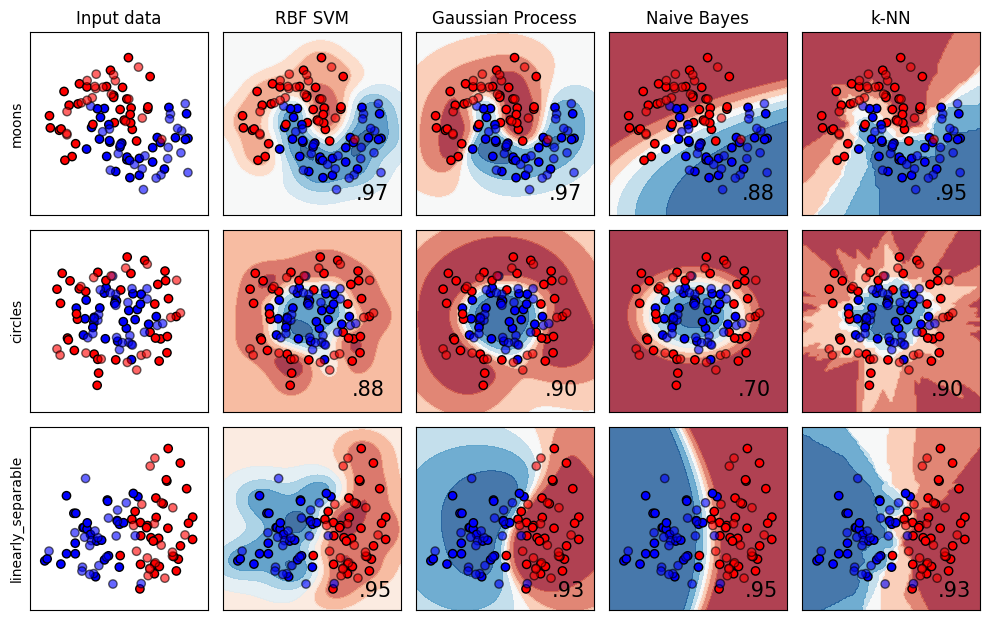

In [117]:
from sklearn.datasets import make_circles, make_classification, make_moons

from sklearn.svm import SVC

from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process import GaussianProcessClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from Part03.classical_algorithms import example_of_algorithms, style_dataframe

classifiers_names = [
    "RBF SVM",
    "Gaussian Process",
    "Naive Bayes",
    "k-NN"
]
classifiers = [
    SVC(gamma=2, C=1, random_state=1),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=1),
    GaussianNB(),
    KNeighborsClassifier(n_neighbors=9),
]

X, y = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]
datasets_names = [
    'moons',
    'circles',
    'linearly_separable',
]

# side effect -> plots everything
results = example_of_algorithms(
    classifiers,
    classifiers_names,
    datasets,
    datasets_names,
)

In [118]:
# create a dataframe of the results
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)
df["dataset"] = pd.Categorical(
    df["dataset"],
    categories=datasets_names,
    ordered=True
)

df.sort_values("classifier", inplace=True)

In [119]:
styled = style_dataframe(
    df,
    [
        ('score', 'high'),
        ('train_runtime', 'low'),
        ('test_runtime', 'low')
    ]
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
RBF SVM,moons,0.975000,0.004262,0.001120
RBF SVM,circles,0.875000,0.001028,0.000463
RBF SVM,linearly_separable,0.950000,0.002958,0.000503
Gaussian Process,moons,0.975000,0.032776,0.000534
Gaussian Process,circles,0.900000,0.049777,0.000786
Gaussian Process,linearly_separable,0.925000,0.086336,0.000485
Naive Bayes,moons,0.875000,0.001282,0.000401
Naive Bayes,circles,0.700000,0.002228,0.000646
Naive Bayes,linearly_separable,0.950000,0.018110,0.000409
k-NN,moons,0.950000,0.031076,0.011903


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATASET_NAME = 'GalaxyMNIST'

results = []
trials = 5
train_size = 1000
test_size = 500
np.random.seed(0)

for name, clf in zip(classifiers_names, classifiers):
    print(f'Starting: {name}')
    for i in range(trials):
        train_start_idx = np.random.randint(0, len(train_flat) - train_size)
        test_start_idx = np.random.randint(0, len(test_flat) - test_size)

        clf_pipeline = make_pipeline(StandardScaler(), clf)

        tr_st = time.perf_counter()
        clf_pipeline.fit(
            train_flat[train_start_idx:train_start_idx + train_size],
            train_labels[train_start_idx:train_start_idx + train_size]
        )
        tr_et = time.perf_counter()
        te_st = time.perf_counter()
        score = clf_pipeline.score(
            test_flat[test_start_idx:test_start_idx + test_size],
            test_labels[test_start_idx:test_start_idx + test_size]
        )
        te_et = time.perf_counter()

        tr_rt = tr_et - tr_st
        te_rt = te_et - te_st
        results.append({
            'classifier': name,
            'dataset': DATASET_NAME, 
            'score': score,
            'train_runtime': tr_rt,
            'test_runtime': te_rt
        })
        print(f'\t{i+1}/{trials} trials', end='\r')
    print(f'\t{trials}/{trials} trials, Done!')
    print(f'Finished: {name}')
print('Done!')

Starting: RBF SVM


KeyboardInterrupt: 

In [120]:
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)

styled = style_dataframe(
    df,
    [
        ('score', 'high'),
        ('train_runtime', 'low'),
        ('test_runtime', 'low')
    ]
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
RBF SVM,moons,0.975000,0.004262,0.001120
Gaussian Process,moons,0.975000,0.032776,0.000534
Naive Bayes,moons,0.875000,0.001282,0.000401
k-NN,moons,0.950000,0.031076,0.011903
RBF SVM,circles,0.875000,0.001028,0.000463
Gaussian Process,circles,0.900000,0.049777,0.000786
Naive Bayes,circles,0.700000,0.002228,0.000646
k-NN,circles,0.900000,0.019534,0.001473
RBF SVM,linearly_separable,0.950000,0.002958,0.000503
Gaussian Process,linearly_separable,0.925000,0.086336,0.000485


In [ ]:
df = df.drop(columns=['dataset'], errors='ignore')

g = df.groupby('classifier', as_index=False)
stats_df = g.agg(
    avg_score=('score', 'mean'),
    std_score=('score', 'std'),
    avg_train_runtime=('train_runtime', 'mean'),
    std_train_runtime=('train_runtime', 'std'),
    avg_test_runtime=('test_runtime', 'mean'),
    std_test_runtime=('test_runtime', 'std')
)

stats_df.sort_values('classifier', inplace=True)

styled = style_dataframe(
    stats_df,
    [
        ('avg_score', 'high'),          # high score is good
        ('avg_train_runtime', 'low'),   # low runtime is good
        ('avg_test_runtime', 'low'),    # low runtime is good
        ('std_score', 'low'),           # low std is good
        ('std_train_runtime', 'low'),   # low std is good
        ('std_test_runtime', 'low')     # low std is good
    ]
)
styled = styled.hide(axis='index')

print(f'Using datset: {DATASET_NAME}')
display(styled)

NameError: name 'DATASET_NAME' is not defined

## 3.2 Neural Networks
We will now start to use neural networks to classify the GalaxyMNIST dataset.
### 3.2.1 Multi-Layer Perceptron (MLP)
In this task you will write all the infrastructure to train and evaluate a neural network on a dataset. We recommend using PyTorch, but you can use any other framework as well. You can use [this](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) tutorial to get started and follow the steps below:
- Define a torch dataset (use a `TensorDataset`) and data loaders for the dataset.
- Design a simple fully connected network.
- Write a training loop which computes output, loss and does an optimization step.
- Write an evaluation function that computes the predictions of the trained model on the test set. 
- Plot the training/test loss and accuracy against the number of epochs.


---

The GalaxyMNIST training and testing datasets are imported at the top.
The MLP neural network is defined in a separate `.py` file and imported here.

The model modules/layers are shown below.
The dataset has ($64 \times 64$) RGB images.
This means the model gets an input tensor with the shape ($\mathrm{batch} \times 3 \times 64 \times 64$).
This is first flattened into a ($\mathrm{batch} \times 12288$) matrix.

Then a linear and a ReLU layer transform the input.
This is done twice.
The final layer is again a linear layer, but without a ReLU function.
This produces an output tensor of shape ($\mathrm{batch} \times 4$), because we want to classify the images into four categories.

The training process is done by calling `training_step()` for each epoch, defined in `NN_training.py`.
This function organizes training and testing functions.

`train()` batches the training dataset and runs the model on it.
It applies the given loss function and optimizer to the model during each batch.
It also keeps track of the loss and accuracy and returns these.

`test()` similarly batches the dataset and runs the model, although this time it is on the test dataset.
The results are also saved and returned.

The performance statistics are returned, and we plot these in graphs below.

In order to actually evaluate the model manually, we would simply call it on the test dataset: `MLP_model(test_dataset.data)`.
To convert the predictions into probabilities, the `.softmax()` method would be used.
This is also shown below.
We print the first 20 results.
Since all except for one are rounded to confidences of $1$ that the image is of a certain class, we also decided to find the image which the model is the least confident in classifying.
Displaying the actual image, it makes sense that the model has some trouble deciding if this is a "smooth cigar" galaxy ($0.4743$ confidence) or an "edge on disk" galaxy ($0.5257$ confidence).
In this case the model actually got the prediction correct, but knowing the test accuracy statistic ($<1$) we must keep in mind that it is not always correct.


In [8]:
from torch import nn
import Part03.MLP_implementation as MLP
from Part03.NN_training import training_step

MLP_model = MLP.NeuralNetwork().to(DEVICE)
print(MLP_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [10]:
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(MLP_model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        MLP_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 0.500602
Completed:  6464/ 8000    loss: 0.688169
Test Accuracy: 71.2 %    Test Avg. loss: 0.674973

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 0.519527
Completed:  6464/ 8000    loss: 0.273292
Test Accuracy: 72.8 %    Test Avg. loss: 0.717403

---------- Epoch 7 ----------
Completed:    64/ 8000    loss: 0.356330
Completed:  6464/ 8000    loss: 0.427038
Test Accuracy: 73.5 %    Test Avg. loss: 0.654286

Done!


In [11]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,0.518857,0.781250,0.674973,0.711500
1,0.508072,0.784375,0.784779,0.662000
2,0.477827,0.796125,0.642091,0.738500
3,0.470209,0.801625,0.670291,0.717500
4,0.440151,0.818000,0.717403,0.727500
5,0.428629,0.818625,0.761842,0.677000
6,0.422633,0.827000,0.651019,0.731500
7,0.412791,0.825625,0.654286,0.735000


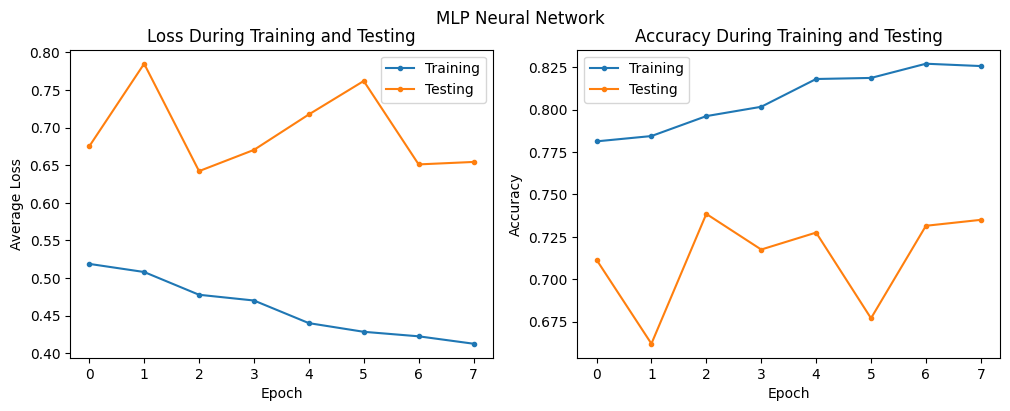

In [12]:
def loss_and_accuracy_plot(axes, df: pd.DataFrame) -> None:
    ax1, ax2 = axes[0], axes[1]

    ax1.plot(df['epoch'], df['training_avg_loss'], label='Training', marker='.')
    ax1.plot(df['epoch'], df['test_avg_loss'], label='Testing', marker='.')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Average Loss')
    ax1.set_title('Loss During Training and Testing')
    ax1.legend()

    ax2.plot(df['epoch'], df['training_accuracy'], label='Training', marker='.')
    ax2.plot(df['epoch'], df['test_accuracy'], label='Testing', marker='.')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy During Training and Testing')
    ax2.legend()

fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
loss_and_accuracy_plot(axes, df)
fig.suptitle('MLP Neural Network')

plt.show()

In [ ]:
# Evaluating explicitly
MLP_model.eval()
with torch.no_grad():
    probs = MLP_model(test_dataset.data.float())

probs = probs.softmax(dim=1)

confidence, pred = probs.max(dim=1)
idx = confidence.argmin()

num_example = 20
print(f'Example of resulting probabilities for first {num_example} predictions:')
print(probs[:num_example])
print()
print(f'Image with least confident classification:')
print(f'Number id: {idx}')
print(f'Probabilities: {probs[idx]}')
print(f'Classes: {test_dataset.classes}')

Example of resulting probabilities for first 20 predictions
tensor([[0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0

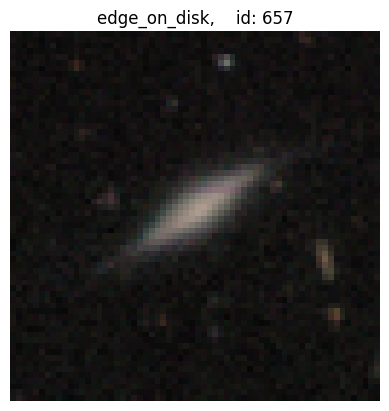

In [115]:
def show_galaxy(image: torch.Tensor, ax, title: str = "") -> None:
    # permute image shape: (C, H, W) -> (H, W, C) for matplotlib
    img = image.permute(1, 2, 0)
    # normalize to [0, 1]
    img = img / 255
    # display
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    return

fig, ax = plt.subplots()
show_galaxy(
    test_dataset.data[idx],
    ax,
    f'{test_dataset.classes[test_dataset.targets[idx]]},    id: {idx}')
plt.show()

### 3.2.2 CNN
MLPs are a simple form of neural networks. However, inserting prior knowledge about the structure of the data can help improve the performance. Convolutional Neural Networks (CNNs) are a type of neural network that is well-suited for image classification tasks.
- Design a CNN and train it on the dataset.
- Can an MLP learn to act like a CNN?

---

We will again use the GalaxyMNIST training and testing datasets.
The CNN neural network is defined in a separate `.py` file and imported here.

The model modules/layers are shown below.
Like before, the model gets an input tensor with the shape ($\mathrm{batch} \times 3 \times 64 \times 64$).
Differently to an MLP, a CNN exploits the image structure, so this time the input is *not* flattened.
Instead, a sequence of convolution, `ReLU` and `MaxPool2d` operations are done on the input.

The convolution operations produce multiple channels of output, corresponding to the number of kernels selected.
The `ReLU` operation introduces nonlinearity behavior, like explained previously.
The `MaxPool2d` calls operate on "windows" of the previous tensor to calculate new values, but they specifically pick the maximum value.
This introduces more nonlinearity and also shrinks the "spatial dimensions" of the image tensor.
The specific parameters of the layers are printed below.
The shape of the input after each layer is given here:

\begin{align*}
    & \text{Layer} && \text{Shape After Applying} \\ \hline \hline
    & \text{Input: } && (\mathrm{batch},  3, 64, 64) \\
    & \text{Conv2d and ReLU: } && (\mathrm{batch}, 32, 64, 64) \\
    & \text{MaxPool2d: } && (\mathrm{batch}, 32, 32, 32) \\
    & \text{Conv2d and ReLU: } && (\mathrm{batch}, 64, 32, 32) \\
    & \text{MaxPool2d: } && (\mathrm{batch}, 64, 16, 16) \\
    & \text{Flatten: } && (\mathrm{batch}, (64 \cdot 16 \cdot 16)) \\
    & \text{Linear and ReLU: } && (\mathrm{batch}, 128) \\
    & \text{Linear: } && (\mathrm{batch}, 4)
\end{align*}

The training loop is the same as before, and we pass the same loss function and optimizer for simplicity.
We graph loss and accuracy during the training process below.

We see better accuracy with this model compared to the MLP NN.
An MLP is more general than a CNN, but the convolutional approach fits well with the image classification task.
With enough training time/data and parameters/layer tuning, the MLP model could probably act like a CNN as well.
However, this would take more parameters and effort, as we will see in the next part.

In [13]:
import Part03.CNN_implementation as CNN

CNN_model = CNN.Neural_Network().to(DEVICE)
print(CNN_model)

Neural_Network(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [14]:
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(CNN_model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(CNN_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        CNN_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 1.384775
Completed:  6464/ 8000    loss: 0.885220
Test Accuracy: 66.8 %    Test Avg. loss: 0.793735

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 0.675620
Completed:  6464/ 8000    loss: 0.392824
Test Accuracy: 75.1 %    Test Avg. loss: 0.587333

---------- Epoch 7 ----------
Completed:    64/ 8000    loss: 0.320691
Completed:  6464/ 8000    loss: 0.461025
Test Accuracy: 77.2 %    Test Avg. loss: 0.561947

Done!


In [15]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,1.077214,0.535250,0.793735,0.668000
1,0.704438,0.711250,0.764472,0.687000
2,0.604900,0.748750,0.585567,0.741500
3,0.516595,0.783875,0.638492,0.734500
4,0.463354,0.808250,0.587333,0.751500
5,0.427431,0.821750,0.579041,0.759500
6,0.373584,0.847500,0.573210,0.759000
7,0.331302,0.864375,0.561947,0.772000


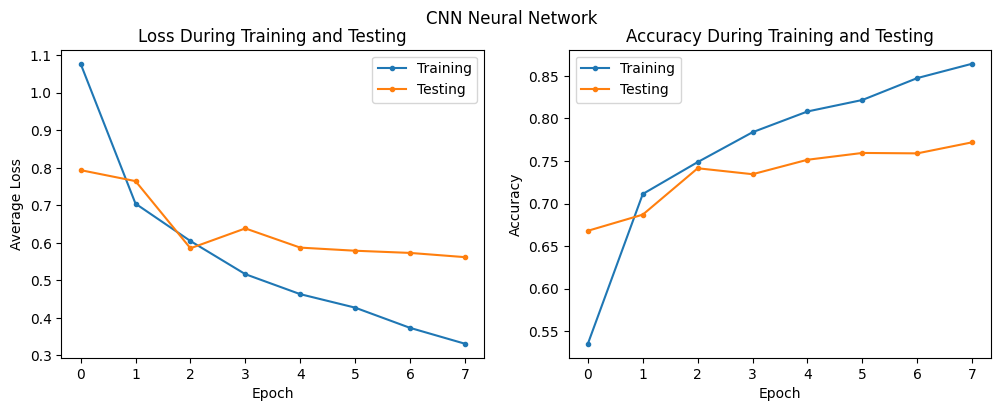

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
loss_and_accuracy_plot(axes, df)
fig.suptitle('CNN Neural Network')

plt.show()

## 3.2.3 Model Analysis
- Print how many parameters each neural network has.
- Does more parameters always mean better performance?

In [17]:
def NN_param_summary(
        model: nn.Module,
        show_empty_modules: bool = False
    ) -> None:
    '''
    Print a list/summary of neural network layers with their names.
    Includes layers with no trainable parameters (e.g. nn.ReLU()).
    '''
    total_num: int = 0

    for name, module in model.named_modules():
        if name == '': continue    # first entry is always the model itself, with empty string as name, (no parameters)
        params = list(module.parameters(recurse=False))

        if (len(params) == 0) and (not show_empty_modules): continue    # detect empties, go to next loop if we dont want to see them
        
        print(f'{name}:')

        if len(params) == 0:
            print('\t(no parameters)')
        else:
            for param_name, param in module.named_parameters(recurse=False):
                print(f'\t{param_name}:')

                n = param.numel()
                print(f'\t\tShape: {tuple(param.shape)}')
                print(f'\t\tNumber: {n:,}')
                total_num += n
    print(f'-------------------------\nTotal parameters: {total_num:,}')

print('MLP Model:')
NN_param_summary(MLP_model)

MLP Model:
linear_relu_stack.0:
	weight:
		Shape: (512, 12288)
		Number: 6,291,456
	bias:
		Shape: (512,)
		Number: 512
linear_relu_stack.2:
	weight:
		Shape: (512, 512)
		Number: 262,144
	bias:
		Shape: (512,)
		Number: 512
linear_relu_stack.4:
	weight:
		Shape: (4, 512)
		Number: 2,048
	bias:
		Shape: (4,)
		Number: 4
-------------------------
Total parameters: 6,556,676


In [18]:
print('CNN Model:')
NN_param_summary(CNN_model)

CNN Model:
conv_layers.0:
	weight:
		Shape: (32, 3, 3, 3)
		Number: 864
	bias:
		Shape: (32,)
		Number: 32
conv_layers.3:
	weight:
		Shape: (64, 32, 3, 3)
		Number: 18,432
	bias:
		Shape: (64,)
		Number: 64
classifier.1:
	weight:
		Shape: (128, 16384)
		Number: 2,097,152
	bias:
		Shape: (128,)
		Number: 128
classifier.3:
	weight:
		Shape: (4, 128)
		Number: 512
	bias:
		Shape: (4,)
		Number: 4
-------------------------
Total parameters: 2,117,188


### 3.2.4 Hyperparameter Tuning
- Use your best model and try to improve its performance by changing its architecture. Possible changes include:
    - Normalization Layers
    - Regularization (Optimizer or Layers)
    - Different Activation Functions
    - Different Learning Rates
    - Increase the number of layers or neurons
- Report which changes seem effective and which do not.

### 3.2.5 Evaluation on the test set
You have now tuned the model hypterparameters to achieve the best accuracy on the test set.
- Why can it become problematic to tune hyperparameters on the test set? What are possible solutions to keep this overfitting in check?